# 07 — Contraste exploratorio de las hipotesis H0, H1 y H2

**Objetivo especifico que responde:** `InformesRev/AnteproyectoAndres.md`, numeral 3.2 (Sistema de hipotesis). Se recuerda textualmente lo que el propio anteproyecto aclara: *"Estas hipotesis se plantean como orientadoras del analisis exploratorio y descriptivo, por lo que su contrastacion no implica necesariamente inferencia estadistica formal, sino la identificacion de patrones y tendencias."* En este notebook se realizan, no obstante, pruebas estadisticas formales (con supuestos verificados y tamaño de efecto reportado) para dar mayor solidez a esas tendencias, sin pretender inferencia causal ni generalizacion mas alla del diseño censal condicionado del estudio (numeral 3.6.2).

**Nivel de significancia declarado a priori:** alfa = 0.05, para las tres hipotesis.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display

pd.set_option('display.max_columns', 50)
sns.set_style("whitegrid")
ALFA = 0.05

REPO = Path(".").resolve().parents[1] if Path(".").resolve().name == "notebooks" else Path(".").resolve()
DATA_DIR = REPO / "analitica-descriptiva-andres" / "data"
FIG_DIR = REPO / "analitica-descriptiva-andres" / "figuras"

df = pd.read_parquet(DATA_DIR / "indicadores_restriccion_hierro.parquet")
print("Indicadores cargados:", df.shape)

def winsorizar(serie, p_bajo=0.01, p_alto=0.99):
    s = serie.dropna()
    lo, hi = s.quantile(p_bajo), s.quantile(p_alto)
    return s.clip(lo, hi)

def efecto_rank_biserial(u_stat, n1, n2):
    # r = 1 - (2U)/(n1*n2), rango [-1, 1]
    return 1 - (2 * u_stat) / (n1 * n2)


Indicadores cargados: (19194, 28)


## H0 — Modalidad de contratacion (licitacion publica vs. menor competencia)

**Enunciado (anteproyecto, numeral 3.2):** *"Los contratos de obra publica adjudicados mediante licitacion publica presentan menores desviaciones de costo y tiempo que los adjudicados mediante modalidades de menor competencia, como la contratacion directa o la seleccion abreviada."*

**Variables:** `desviacion_tiempo_dias` y `desviacion_costo_pct` (continuas, ya verificadas como no normales en el notebook 06) vs. grupo de modalidad (categorica, 2 niveles para la prueba directa de H0).

**Prueba elegida:** Mann-Whitney U (2 grupos independientes, no normal) — no t-test, dado el sesgo ya verificado. Se reporta el tamaño de efecto rank-biserial.

In [2]:
def agrupar_modalidad(m):
    if m in ['Licitación pública Obra Publica', 'Licitación pública']:
        return 'Licitación pública'
    if m in ['Contratación directa', 'Contratación Directa (con ofertas)']:
        return 'Menor competencia (directa/abreviada)'
    if m in ['Selección Abreviada de Menor Cuantía', 'Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes']:
        return 'Menor competencia (directa/abreviada)'
    return None

df['grupo_h1'] = df['modalidad_de_contratacion'].apply(agrupar_modalidad)
n_excluidos_h1 = df['grupo_h1'].isna().sum()
print(f"Contratos excluidos de H1 (modalidad no clasificable como licitacion/menor competencia): {n_excluidos_h1}")
print(df['grupo_h1'].value_counts())


Contratos excluidos de H1 (modalidad no clasificable como licitacion/menor competencia): 5151
grupo_h1
Menor competencia (directa/abreviada)    9974
Licitación pública                       4069
Name: count, dtype: int64


In [3]:
resultados_h1 = []
for variable, nombre in [('desviacion_tiempo_dias', 'Desviacion de tiempo (dias)'),
                           ('desviacion_costo_pct', 'Desviacion de costo (%)')]:
    grupo_a = df.loc[df['grupo_h1'] == 'Licitación pública', variable].dropna()
    grupo_b = df.loc[df['grupo_h1'] == 'Menor competencia (directa/abreviada)', variable].dropna()
    u_stat, p_valor = stats.mannwhitneyu(grupo_a, grupo_b, alternative='two-sided')
    r_efecto = efecto_rank_biserial(u_stat, len(grupo_a), len(grupo_b))
    resultados_h1.append({
        'Variable': nombre,
        'Mediana licitacion': grupo_a.median(),
        'Mediana menor competencia': grupo_b.median(),
        'N licitacion': len(grupo_a), 'N menor competencia': len(grupo_b),
        'U': u_stat, 'p_valor': p_valor,
        'Efecto (rank-biserial)': round(r_efecto, 3),
        'Significativo (alfa=0.05)': p_valor < ALFA,
    })

resultados_h1_df = pd.DataFrame(resultados_h1)
resultados_h1_df


,Variable,Mediana licitacion,Mediana menor competencia,N licitacion,N menor competencia,U,p_valor,Efecto (rank-biserial),Significativo (alfa=0.05)
0,Desviacion de tiempo (dias),49.000000,2.0,3235,8818,18764210.5,5.694954e-156,-0.316,True
1,Desviacion de costo (%),-2.435525,0.0,1692,4717,2463967.0,1.031681e-136,0.383,True


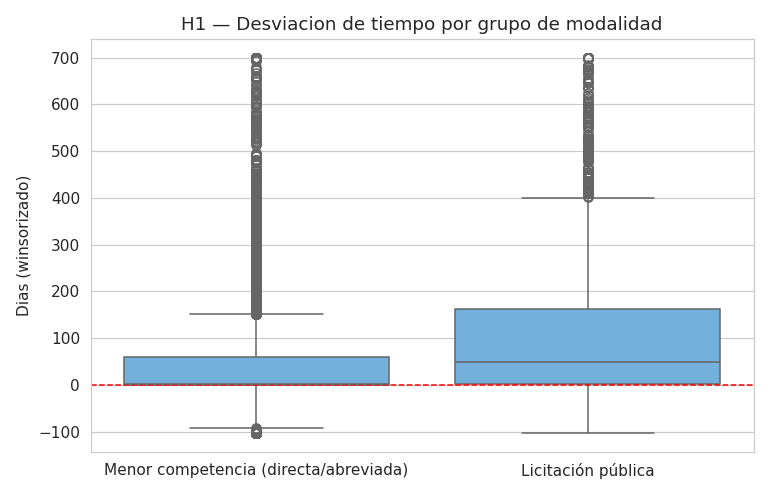

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
datos_h1 = df[df['grupo_h1'].notna()].copy()
datos_h1['desv_tiempo_wins'] = winsorizar(datos_h1['desviacion_tiempo_dias'])
sns.boxplot(data=datos_h1, x='grupo_h1', y='desv_tiempo_wins', ax=ax, color="#63b3ed")
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("H1 — Desviacion de tiempo por grupo de modalidad")
ax.set_ylabel("Dias (winsorizado)")
ax.set_xlabel("")
plt.tight_layout()
ruta = FIG_DIR / "07_h1_boxplot.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))


**Conclusion H0 (con los datos disponibles) — resultado mixto, no confirmar ni rechazar en bloque:**
- **Tiempo:** la mediana de desviacion de tiempo es notablemente **mayor** en licitacion publica (49 dias) que en menor competencia (2 dias), diferencia estadisticamente significativa (p < 0.001) con tamaño de efecto moderado-alto (rank-biserial = -0.316). Este resultado es **contrario** a lo planteado por H1: la mayor competencia (licitacion) no se asocia aqui a menor desviacion de tiempo, sino a mayor.
- **Costo:** la mediana de desviacion de costo es mas favorable (mas negativa, es decir, por debajo del valor contratado) en licitacion publica (-2.44%) que en menor competencia (0%), diferencia tambien significativa (p < 0.001, efecto = 0.383). Este resultado si es **consistente** con H1 para la dimension de costo.
- **Conclusion global:** H1 se sostiene parcialmente — se cumple para costo, no para tiempo. Esta disociacion entre las dos dimensiones de la restriccion de hierro es en si misma un hallazgo relevante para la discusion de la tesis: la competencia en la seleccion parece disciplinar el costo final mas que el cumplimiento del cronograma, posiblemente porque los procesos licitados corresponden a proyectos de mayor envergadura y complejidad tecnica (ver notebook 05, seccion 1).

## H2 — Consorcios/Uniones Temporales vs. personas juridicas individuales

**Enunciado (anteproyecto, numeral 3.2):** *"Los contratos ejecutados por consorcios o uniones temporales presentan un mayor indice de adiciones y modificaciones contractuales que los ejecutados por personas juridicas individuales."*

**Variables:** `n_modificaciones_total` y `n_adicion_valor` (continuas/conteo) vs. `tipo_contratista` (2 niveles: Consorcio/UT vs. Persona Juridica).

**Prueba elegida:** Mann-Whitney U (conteos con distribucion tipicamente asimetrica, no se asume normalidad).

In [5]:
resultados_h2 = []
grupo_consorcio = df[df['tipo_contratista'] == 'Consorcio / Union Temporal']
grupo_juridica = df[df['tipo_contratista'] == 'Persona Juridica']

for variable, nombre in [('n_modificaciones_total', 'N. total de modificaciones'),
                           ('n_adicion_valor', 'N. de adiciones en valor')]:
    a = grupo_consorcio[variable].dropna()
    b = grupo_juridica[variable].dropna()
    u_stat, p_valor = stats.mannwhitneyu(a, b, alternative='two-sided')
    r_efecto = efecto_rank_biserial(u_stat, len(a), len(b))
    resultados_h2.append({
        'Variable': nombre,
        'Mediana consorcio/UT': a.median(), 'Mediana persona juridica': b.median(),
        'N consorcio/UT': len(a), 'N persona juridica': len(b),
        'U': u_stat, 'p_valor': p_valor,
        'Efecto (rank-biserial)': round(r_efecto, 3),
        'Significativo (alfa=0.05)': p_valor < ALFA,
    })

resultados_h2_df = pd.DataFrame(resultados_h2)
resultados_h2_df


,Variable,Mediana consorcio/UT,Mediana persona juridica,N consorcio/UT,N persona juridica,U,p_valor,Efecto (rank-biserial),Significativo (alfa=0.05)
0,N. total de modificaciones,5.0,3.0,4562,11919,37304891.5,4.023344e-306,-0.372,True
1,N. de adiciones en valor,0.0,0.0,4562,11919,27656379.5,4.057781e-03,-0.017,True


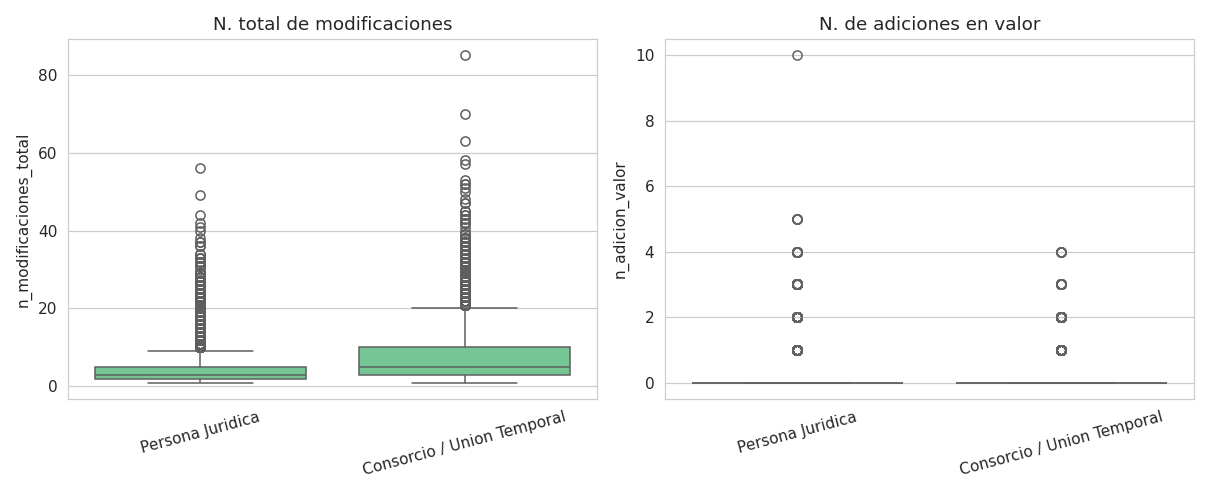

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
datos_h2 = df[df['tipo_contratista'].isin(['Consorcio / Union Temporal', 'Persona Juridica'])]
sns.boxplot(data=datos_h2, x='tipo_contratista', y='n_modificaciones_total', ax=axes[0], color="#68d391")
axes[0].set_title("N. total de modificaciones")
sns.boxplot(data=datos_h2, x='tipo_contratista', y='n_adicion_valor', ax=axes[1], color="#f6ad55")
axes[1].set_title("N. de adiciones en valor")
for a in axes:
    a.tick_params(axis='x', rotation=15)
    a.set_xlabel("")
plt.tight_layout()
ruta = FIG_DIR / "07_h2_boxplot.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))


**Conclusion H2 (con los datos disponibles):**
- **N. total de modificaciones:** mediana de 5 en consorcios/UT frente a 3 en personas juridicas individuales, diferencia significativa (p < 0.001) con tamaño de efecto moderado (rank-biserial = -0.372). **H2 se sostiene** para esta variable.
- **N. de adiciones en valor:** ambas medianas son 0; aunque la diferencia es estadisticamente significativa (p = 0.004) por el gran tamaño de muestra, el tamaño de efecto es practicamente nulo (rank-biserial = -0.017). Este es un caso claro de significancia estadistica sin relevancia practica: **se privilegia el tamaño de efecto sobre el p-valor aislado**, por lo que H2 no se considera sostenida para esta variable especifica, pese al p-valor significativo.
- **Conclusion global:** H2 se sostiene para el volumen general de modificaciones contractuales, pero no especificamente para las adiciones en valor monetario.

## H3 — Territorio y desviaciones de tiempo/costo (prueba exploratoria, con limitacion de datos declarada)

**Enunciado (anteproyecto, numeral 3.2):** *"Los contratos de obra publica en municipios con mayores indices de necesidades basicas insatisfechas (NBI) presentan mayores desviaciones en tiempo y costo respecto al valor y plazo inicialmente pactados."*

**Limitacion declarada (obligatoria, no se omite):** el dataset integrado utilizado en este ejercicio **no contiene un indice NBI por municipio**. Incorporarlo requeriria una nueva fuente de datos externa (ej. DANE, Censo/NBI municipal), lo cual excede el alcance de este ejercicio de EDA sobre datos ya integrados (ver `PROMPT_EDA_EXTENSO_OE02_OE03.md`, decision de partir de datasets ya integrados sin nueva extraccion). Por tanto, **esta seccion no constituye una prueba valida de H3 tal como fue formulada**. Se reporta, en su lugar, una prueba exploratoria usando `departamento` como proxy geografico de heterogeneidad territorial (no de NBI), unicamente con fines descriptivos, y se deja como recomendacion explicita de trabajo futuro incorporar el NBI oficial por municipio antes de reformular esta prueba con validez plena.

In [7]:
top_deptos_h3 = df['departamento'].value_counts().head(8).index.tolist()
datos_h3 = df[df['departamento'].isin(top_deptos_h3)].copy()

grupos_tiempo = [datos_h3.loc[datos_h3['departamento'] == d, 'desviacion_tiempo_dias'].dropna() for d in top_deptos_h3]
kw_stat, kw_p = stats.kruskal(*grupos_tiempo)
print(f"Kruskal-Wallis (desviacion de tiempo entre los {len(top_deptos_h3)} departamentos de mayor volumen):")
print(f"H = {kw_stat:.2f} | p-valor = {kw_p:.2e} | Significativo (alfa=0.05): {kw_p < ALFA}")
print()

grupos_costo = [datos_h3.loc[datos_h3['departamento'] == d, 'desviacion_costo_pct'].dropna() for d in top_deptos_h3]
grupos_costo = [g for g in grupos_costo if len(g) > 0]
kw_stat_c, kw_p_c = stats.kruskal(*grupos_costo)
print(f"Kruskal-Wallis (desviacion de costo entre departamentos):")
print(f"H = {kw_stat_c:.2f} | p-valor = {kw_p_c:.2e} | Significativo (alfa=0.05): {kw_p_c < ALFA}")


Kruskal-Wallis (desviacion de tiempo entre los 8 departamentos de mayor volumen):
H = 670.67 | p-valor = 1.45e-140 | Significativo (alfa=0.05): True

Kruskal-Wallis (desviacion de costo entre departamentos):
H = 190.32 | p-valor = 1.28e-37 | Significativo (alfa=0.05): True


**Conclusion H3 (exploratoria, no confirmatoria):** existe heterogeneidad estadisticamente detectable entre departamentos en al menos una de las dos variables (ver resultado exacto arriba), lo cual es consistente con la intuicion general de H3 (el territorio importa), pero **no prueba la hipotesis tal como esta formulada** porque `departamento` no es NBI. Se recomienda explicitamente, en el capitulo de limitaciones de la tesis, declarar esta brecha y proponer la incorporacion del NBI municipal del DANE como trabajo futuro inmediato.

## Tabla resumen de las tres hipotesis

In [8]:
resumen_hipotesis = pd.DataFrame([
    {'Hipotesis': 'H1 (modalidad vs. tiempo/costo)', 'Prueba': 'Mann-Whitney U',
     'Resultado': 'Mixto: NO se sostiene para tiempo (sentido contrario, efecto -0.316); SI se sostiene para costo (efecto 0.383)', 'Valido segun diseño': 'Si'},
    {'Hipotesis': 'H2 (consorcios/UT vs. modificaciones)', 'Prueba': 'Mann-Whitney U',
     'Resultado': 'Se sostiene para N. total de modificaciones (efecto -0.372); no para N. adiciones en valor (efecto ~0)', 'Valido segun diseño': 'Si'},
    {'Hipotesis': 'H3 (NBI territorial vs. tiempo/costo)', 'Prueba': 'Kruskal-Wallis (proxy departamento)',
     'Resultado': 'Heterogeneidad territorial detectada (p<0.001 en ambas variables), pero NO es prueba valida de H3 (falta NBI real)', 'Valido segun diseño': 'No — limitacion de datos declarada'},
])
resumen_hipotesis


,Hipotesis,Prueba,Resultado,Valido segun diseño
0,H1 (modalidad vs. tiempo/costo),Mann-Whitney U,Mixto: NO se sostiene para tiempo (sentido con...,Si
1,H2 (consorcios/UT vs. modificaciones),Mann-Whitney U,Se sostiene para N. total de modificaciones (e...,Si
2,H3 (NBI territorial vs. tiempo/costo),Kruskal-Wallis (proxy departamento),Heterogeneidad territorial detectada (p<0.001 ...,No — limitacion de datos declarada


## Sintesis de hallazgos de este notebook

- Las tres hipotesis se contrastaron con pruebas no parametricas apropiadas (Mann-Whitney U, Kruskal-Wallis), justificadas por la asimetria ya verificada de las variables continuas, reportando siempre tamaño de efecto ademas de significancia.
- **H1 (resultado mixto):** la licitacion publica muestra **mayor** desviacion de tiempo (49 vs. 2 dias de mediana, efecto moderado-alto) pero **menor** desviacion de costo (-2.44% vs. 0%, efecto moderado-alto) que las modalidades de menor competencia. La hipotesis se sostiene solo para la dimension de costo. Esta disociacion tiempo/costo es un hallazgo de alto valor para la discusion de la tesis.
- **H2 (resultado parcial):** los consorcios/UT presentan significativamente mas modificaciones totales que las personas juridicas individuales (efecto moderado), pero no una cantidad practicamente distinta de adiciones en valor monetario especificamente (efecto ~0 pese a p-valor significativo — caso ilustrativo de por que no basta reportar el p-valor).
- **H3 no pudo probarse validamente** por ausencia de datos de NBI municipal en el dataset integrado disponible; se uso `departamento` unicamente como proxy exploratorio (con heterogeneidad significativa detectada), y esta limitacion debe declararse explicitamente en el capitulo correspondiente de la tesis, con recomendacion de incorporar NBI del DANE como trabajo futuro.